<a href="https://colab.research.google.com/github/ironspiritjeff/Heart-Disease-Classifier/blob/main/SciKit_Learning_Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
heart_disease = pd.read_csv('heart-disease.csv')
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = heart_disease.drop('target', axis = 1)
y = heart_disease['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [ ]:
clf = RandomForestClassifier()
np.random.seed(7)
model = clf.fit(X_train, y_train)
y_preds = clf.predict(X_test)

In [ ]:
clf.score(X_train, y_train)

1.0

In [ ]:
clf.score(X_test, y_test)

0.8032786885245902

### Evaluating Model Performance with Cross-Validation

Cross-validation is a technique to assess how the results of a statistical analysis will generalize to an independent data set. It is mainly used in settings where the goal is prediction, and one wants to estimate how accurately a predictive model will perform in practice. In a prediction problem, a model is usually given a dataset of known data on which training is run, and a dataset of unknown data (or first seen data) against which the model is tested.

Let's apply 5-fold cross-validation to our `RandomForestClassifier` to get a more robust score.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(clf, X, y, cv=5)

print(f'Cross Val Scores: {cv_scores}')
print(f'Mean CV Score: {np.mean(cv_scores)*100:.3f}')
print(f"Standard deviation of CV Scores: {np.std(cv_scores):.3f}")

Cross Val Scores: [0.85245902 0.86885246 0.81967213 0.81666667 0.78333333]
Mean CV Score: 82.820
Standard deviation of CV Scores: 0.030


Feature Importances:


,feature,importance
12,thal,0.125712
11,ca,0.116831
9,oldpeak,0.114055
7,thalach,0.111577
2,cp,0.100018
0,age,0.097722
4,chol,0.074629
3,trestbps,0.069489
8,exang,0.057660
10,slope,0.056780


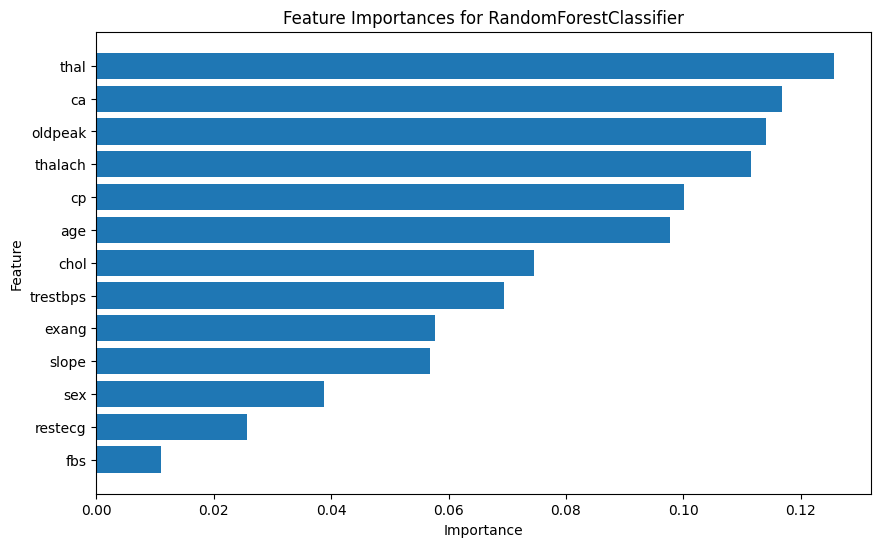

In [ ]:
# Get feature importances from the trained RandomForestClassifier
feature_importances = clf.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
features_df = features_df.sort_values(by='importance', ascending=False)

print("Feature Importances:")
display(features_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features_df['feature'], features_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances for RandomForestClassifier')
plt.gca().invert_yaxis() # To have the most important feature at the top
plt.show()

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

To see which model performs best, we'll do the following:

Instantiate each model in a dictionary

Create an empty results dictionary

Fit each model on the training data

Score each model on the test data

Check the results

In [ ]:
model_dict = {
    "RFC": clf,
    "SVC": SVC(),
    "LinearSVC": LinearSVC(),
    "Logistic Regression": LogisticRegression(),
    "KNeighbors": KNeighborsClassifier()}

results = {}

In [ ]:
for model_name, model in model_dict.items():
  model.fit(X_train, y_train)
  results[model_name] = model.score(X_test,y_test)

results


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'RFC': 0.8688524590163934,
 'SVC': 0.6557377049180327,
 'LinearSVC': 0.8852459016393442,
 'Logistic Regression': 0.8688524590163934,
 'KNeighbors': 0.6065573770491803}

Let's perform cross-validation for all the models in our `model_dict` to get a more robust understanding of their performance.

In [ ]:
cv_results = {}

for model_name, model in model_dict.items():
    # Perform 5-fold cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5)
    score = model.score(X_test, y_test)

    cv_results[model_name] = {
        'initial_score': score,
        'mean_score': np.mean(cv_scores),
        'std_score': np.std(cv_scores),
        'scores': cv_scores
    }

print("Cross-Validation Results for all Models:")
for model_name, metrics in cv_results.items():
    print(f"\nModel: {model_name}")
    print(f"  Baseline Score: {metrics['initial_score']:.4f}") # Corrected this line
    print(f"  Mean CV Score: {metrics['mean_score']:.4f}")
    print(f"  Std CV Score: {metrics['std_score']:.4f}")
    print(f"  All CV Scores: {metrics['scores']}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross-Validation Results for all Models:

Model: RFC
  Baseline Score: 0.8689
  Mean CV Score: 0.8283
  Std CV Score: 0.0476
  All CV Scores: [0.85245902 0.90163934 0.7704918  0.83333333 0.78333333]

Model: SVC
  Baseline Score: 0.6557
  Mean CV Score: 0.6435
  Std CV Score: 0.0580
  All CV Scores: [0.60655738 0.60655738 0.73770492 0.68333333 0.58333333]

Model: LinearSVC
  Baseline Score: 0.8852
  Mean CV Score: 0.8216
  Std CV Score: 0.0557
  All CV Scores: [0.81967213 0.86885246 0.83606557 0.86666667 0.71666667]

Model: Logistic Regression
  Baseline Score: 0.8689
  Mean CV Score: 0.8282
  Std CV Score: 0.0422
  All CV Scores: [0.81967213 0.86885246 0.85245902 0.85       0.75      ]

Model: KNeighbors
  Baseline Score: 0.6066
  Mean CV Score: 0.6439
  Std CV Score: 0.0538
  All CV Scores: [0.60655738 0.6557377  0.57377049 0.73333333 0.65      ]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
np.random.seed(7)
for model_name, model in model_dict.items():
    model.fit(X_train, y_train)
    results[model_name] = model.score(X_test, y_test)

# View the results
results

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'RFC': 0.8032786885245902,
 'SVC': 0.6557377049180327,
 'LinearSVC': 0.8852459016393442,
 'Logistic Regression': 0.8688524590163934,
 'KNeighbors': 0.6065573770491803}

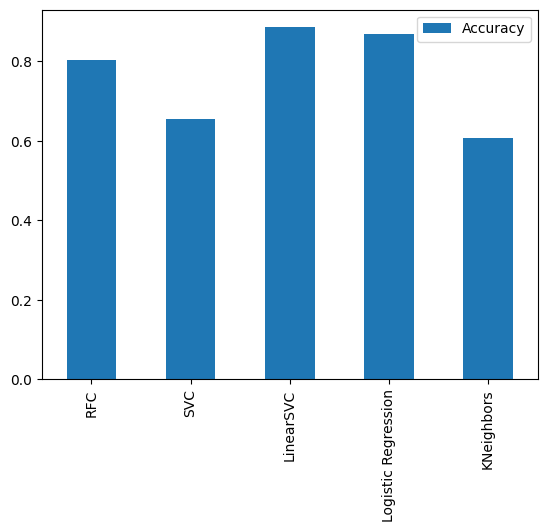

In [ ]:
# Create a bar plot of the results dataframe using plot.bar()
results_df = pd.DataFrame(results.values(),
                          results.keys(),
                          columns=['Accuracy'])
results_df.plot.bar();

In [ ]:
# Different LogisticRegression hyperparameters
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

In [ ]:
np.random.seed(7)

from sklearn.model_selection import RandomizedSearchCV

# Setup an instance of RandomizedSearchCV with a LogisticRegression() estimator,
# our log_reg_grid as the param_distributions, a cv of 5 and n_iter of 5.
rs_log_reg = RandomizedSearchCV(estimator=LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter = 5 ,
                                verbose=2)

rs_log_reg.fit(X_train, y_train)
# Fit the instance of RandomizedSearchCV
###

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END .........C=0.00026366508987303583, solver=liblinear; total time=   0.0s
[CV] END .........C=0.00026366508987303583, solver=liblinear; total time=   0.0s
[CV] END .........C=0.00026366508987303583, solver=liblinear; total time=   0.0s
[CV] END .........C=0.00026366508987303583, solver=liblinear; total time=   0.0s
[CV] END .........C=0.00026366508987303583, solver=liblinear; total time=   0.0s
[CV] END ...............C=1438.44988828766, solver=liblinear; total time=   0.0s
[CV] END ...............C=1438.44988828766, solver=liblinear; total time=   0.0s
[CV] END ...............C=1438.44988828766, solver=liblinear; total time=   0.0s
[CV] END ...............C=1438.44988828766, solver=liblinear; total time=   0.0s
[CV] END ...............C=1438.44988828766, solver=liblinear; total time=   0.0s
[CV] END ..........C=0.0006951927961775605, solver=liblinear; total time=   0.0s
[CV] END ..........C=0.0006951927961775605, solve

RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=5,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=2)

In [ ]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(4.281332398719396)}

In [ ]:
rs_log_reg.score(X_test, y_test)

0.8688524590163934

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
import numpy as np

# Get the best parameters for Logistic Regression from RandomizedSearchCV
best_log_reg_params = rs_log_reg.best_params_

# Instantiate Logistic Regression with the best parameters
log_reg_tuned = LogisticRegression(**best_log_reg_params)

# Instantiate StratifiedKFold
# n_splits (number of folds) is typically 5 or 10
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

# Perform stratified cross-validation
stratified_cv_scores = cross_val_score(log_reg_tuned, X, y, cv=skf)

print(f"Stratified Cross-validation scores for Logistic Regression: {stratified_cv_scores}")
print(f"Mean Stratified CV Score: {np.mean(stratified_cv_scores):.4f}")
print(f"Standard deviation of Stratified CV Scores: {np.std(stratified_cv_scores):.4f}")

Stratified Cross-validation scores for Logistic Regression: [0.85245902 0.80327869 0.83606557 0.88333333 0.8       ]
Mean Stratified CV Score: 0.8350
Standard deviation of Stratified CV Scores: 0.0312


In [ ]:
# Instantiate a LogisticRegression classifier using the best hyperparameters from RandomizedSearchCV
clf = LogisticRegression(**rs_log_reg.best_params_)

clf.fit(X_train, y_train)
# Fit the new instance of LogisticRegression with the best hyperparameters on the training data
###

LogisticRegression(C=np.float64(4.281332398719396), solver='liblinear')

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_curve

In [ ]:
y_preds = clf.predict(X_test)

In [ ]:
cm = confusion_matrix(y_test, y_preds)
cm

array([[20,  6],
       [ 2, 33]])

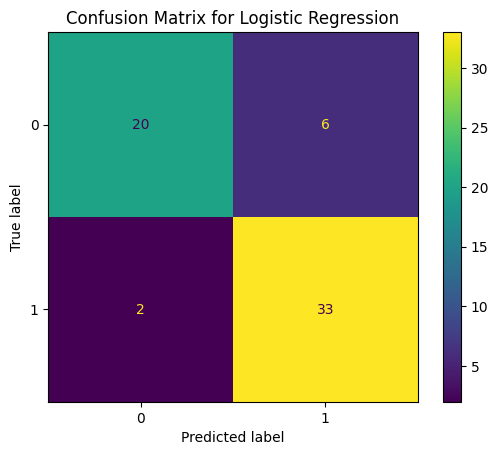

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels= clf.classes_)
disp.plot()
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [ ]:
print(classification_report(y_test, y_preds))


              precision    recall  f1-score   support

           0       0.91      0.77      0.83        26
           1       0.85      0.94      0.89        35

    accuracy                           0.87        61
   macro avg       0.88      0.86      0.86        61
weighted avg       0.87      0.87      0.87        61



In [ ]:
precision_score(y_test, y_preds)

0.8461538461538461

In [ ]:
recall_score(y_test, y_preds)

0.9428571428571428

In [ ]:
f1_score(y_test, y_preds)

0.8918918918918919

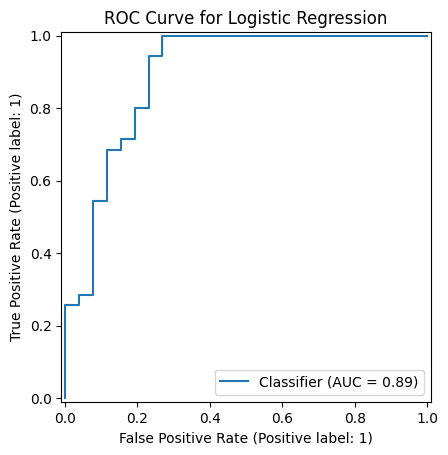

In [ ]:
from sklearn.metrics import RocCurveDisplay
# Calculate predicted probabilities for the positive class (class 1)
y_probs = clf.predict_proba(X_test)[:, 1]

#Plot ROC Curve
RocCurveDisplay.from_predictions (y_test, y_probs)
plt.title ("ROC Curve for Logistic Regression")
plt.show()


# Calculate predicted probabilities for the positive class (class 1)
# y_probs = clf.predict_proba(X_test)[:, 1]

# # Plot ROC curve
# RocCurveDisplay.from_predictions(y_test, y_probs)
# plt.title('ROC Curve for Logistic Regression')
# plt.show()

In [ ]:
cross_val_score(clf, X, y,
                scoring = 'accuracy',
                cv=5)

array([0.81967213, 0.86885246, 0.83606557, 0.86666667, 0.71666667])

In [ ]:
cross_val_acc = np.mean(cross_val_score(clf, X, y,
                              scoring = 'accuracy',
                              cv=5))
cross_val_acc

np.float64(0.8215846994535518)

In [ ]:
cross_val_recall = np.mean(cross_val_score(clf, X, y,
                              scoring = 'recall',
                              cv=5))
cross_val_recall

np.float64(0.8727272727272727)

In [ ]:
cross_val_precision = np.mean(cross_val_score(clf, X, y,
                              scoring = 'precision',
                              cv=5))
cross_val_precision

np.float64(0.8179096985548598)

In [ ]:
cross_val_f1 = np.mean(cross_val_score(clf, X, y,
                              scoring = 'f1',
                              cv=5))
cross_val_f1

np.float64(0.8429665874032072)

In [ ]:
from joblib import dump, load
# Use the dump function to export the trained model to file
dump(clf, "trained-classifier.joblib")

['trained-classifier.joblib']

In [ ]:
# Use the load function to import the trained model you just exported
loaded_clf = load('trained-classifier.joblib')

# Evaluate the loaded trained model on the test data
loaded_clf.score(X_test, y_test)

0.8688524590163934

In [ ]:
car_sales = pd.read_csv('car-sales-extended-missing-data.csv')

car_sales.dropna(subset=['Price'], inplace=True)
X = car_sales.drop('Price', axis=1)
y = car_sales['Price']

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # Corrected: 'pipeline' to 'Pipeline'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# Use SimpleImporter to create imputation strategies
cat_imputer = SimpleImputer(strategy = 'constant', fill_value = 'missing')
door_imputer = SimpleImputer(strategy = 'constant', fill_value=4)
num_imputer = SimpleImputer(strategy = 'mean')

# Put columns into categories based on which strategy is needed
cat_features = ['Make', 'Colour']
door_features = ['Doors']
num_features = ['Odometer (KM)']

# Create Transformer that applies the strategies to the columns:
imputer = ColumnTransformer([
    ('cat_imputer', cat_imputer, cat_features),
    ('door_imputer', door_imputer, door_features),
    ('num_imputer', num_imputer, num_features) ])

# Fill with transform and fit
filled_X_train = imputer.fit_transform(X_train)
filled_X_test = imputer.transform(X_test)
filled_X_train

array([['Toyota', 'White', 4.0, 108569.0],
       ['missing', 'White', 4.0, 138274.0],
       ['BMW', 'Blue', 5.0, 50363.0],
       ...,
       ['Honda', 'missing', 4.0, 213793.0],
       ['Nissan', 'Blue', 3.0, 181577.0],
       ['Nissan', 'White', 4.0, 127386.0]], dtype=object)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

cat_transformer = Pipeline(steps=[
    ('cat_imputer', cat_imputer),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) ])

door_transformer = Pipeline(steps=[('door_imputer', door_imputer)])

num_transformer = Pipeline(steps=[('num_imputer', num_imputer)])

In [ ]:
preprocessor = ColumnTransformer(transformers = [
      ('cat', cat_transformer, cat_features),
      ('door', door_transformer, door_features),
      ('num', num_transformer, num_features) ])

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [ ]:
regression_models = {'Ridge': Ridge(),
                     'SVR_linear': SVR(kernel='linear'),
                     'SVR_rbf': SVR(kernel='rbf'),
                     'RandomForestRegressor': RandomForestRegressor()}
regression_results = {}

In [ ]:
X = car_sales.drop("Price", axis=1)
y = car_sales['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=7)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((760, 4), (190, 4), (760,), (190,))

In [ ]:
for model_name, model in regression_models.items():

  model_pipeline=Pipeline(steps=[('preprocessor', preprocessor),
                                 ('model', model)])
  print(f'fitting {model_name}...')
  model_pipeline.fit(X_train, y_train)

  print(f'Scoring {model_name}...')
  regression_results[model_name]=model_pipeline.score(X_test, y_test)

fitting Ridge...
Scoring Ridge...
fitting SVR_linear...
Scoring SVR_linear...
fitting SVR_rbf...
Scoring SVR_rbf...
fitting RandomForestRegressor...
Scoring RandomForestRegressor...


In [ ]:
print(regression_results)


{'Ridge': 0.2901512898730799, 'SVR_linear': 0.13426461981273408, 'SVR_rbf': -0.053627571786138084, 'RandomForestRegressor': 0.06188269818061909}


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('model', model) ])
ridge_pipeline.fit(X_train, y_train)

y_preds = ridge_pipeline.predict(X_test)

y_preds[:50]

array([15487.01      , 19955.9       , 19260.48      ,  9463.47      ,
       12047.95416667, 12096.45      , 14532.2       , 10037.31      ,
       18701.12      , 21066.09      , 15858.11      , 26221.39      ,
        8713.25      , 19915.34      , 19361.39      ,  5996.86      ,
       11571.8       ,  9413.89      , 18162.66      , 12441.27      ,
       19350.75      , 10209.73      , 21831.99      , 17850.63      ,
        9618.67916667, 15334.29      , 11973.83      , 14993.4       ,
       23212.12      , 15838.18      , 20092.        , 20633.07      ,
       15529.18118687,  9962.91      , 13936.14      , 16911.5       ,
       15938.29507576, 23448.24      , 18775.14      , 13923.59      ,
       41162.65      ,  8926.89      , 18843.75      , 19997.32      ,
       19218.54      ,  7035.4       , 14147.75      , 13555.99      ,
       11455.92      , 12473.750921  ])

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_preds))
rmse

np.float64(7535.720762169613)

In [ ]:
mae = mean_absolute_error(y_test, y_preds)
mae

5974.102633389125

In [ ]:
r2 = r2_score(y_test, y_preds)
r2

0.16242671631375372